In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import shutil
from google.colab import files

# Определяем пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
shutil.move(source_path, destination_path)

# Устанавливаем права доступа
os.chmod(destination_path, 0o600)

# Загружаем файл
uploaded = files.upload()
!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones

with zipfile.ZipFile('human-activity-recognition-with-smartphones.zip', 'r') as zip_ref:
    zip_ref.extractall('human-activity-recognition-with-smartphones')

    # Показать файлы в директории
print(os.listdir('human-activity-recognition-with-smartphones'))

# Замените 'zoo_data-1.csv' на правильное имя файла
df = pd.read_csv('human-activity-recognition-with-smartphones/test.csv')

# Просматриваем первые несколько строк датасета
print(df.head())

# Получаем общую информацию о датасете
print(df.info())

# Выводим статистические данные о числовых столбцах
print(df.describe())


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
  0% 0.00/24.5M [00:00<?, ?B/s]
100% 24.5M/24.5M [00:00<00:00, 1.03GB/s]
['test.csv', 'train.csv']
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.257178          -0.023285          -0.014654         -0.938404   
1           0.286027          -0.013163          -0.119083         -0.975415   
2           0.275485          -0.026050          -0.118152         -0.993819   
3           0.270298          -0.032614          -0.117520         -0.994743   
4           0.274833          -0.027848          -0.129527         -0.993852   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.920091         -0.667683         -0.952501         -0.925249   
1         -0.967458         -0.944958         -0.986799         -0.968401   
2         -0.969926         -0.962748   

In [2]:
# Импортируем необходимые библиотеки
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Загрузка данных
df_train = pd.read_csv('human-activity-recognition-with-smartphones/train.csv')
df_test = pd.read_csv('human-activity-recognition-with-smartphones/test.csv')

# Разделение данных на обучающий и тестовый наборы
X_train = df_train.iloc[:, :-1].values
y_train = df_train.iloc[:, -1].values

X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# Создание модели Gradient Boosting Classifier
gb_classifier = HistGradientBoostingClassifier(max_iter=100, max_depth=3, learning_rate=0.1, random_state=42)

# Обучение модели на обучающем наборе данных
gb_classifier.fit(X_train, y_train)

# Предсказание классов на тестовом наборе данных
y_pred = gb_classifier.predict(X_test)

# Вывод полного отчета
report = classification_report(y_test, y_pred)
print(report)

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.94      0.85      0.89       491
          STANDING       0.87      0.95      0.91       532
           WALKING       0.95      0.99      0.97       496
WALKING_DOWNSTAIRS       0.98      0.93      0.95       420
  WALKING_UPSTAIRS       0.93      0.94      0.94       471

          accuracy                           0.94      2947
         macro avg       0.95      0.94      0.94      2947
      weighted avg       0.95      0.94      0.94      2947



Train: (5146, 562), Test: (2206, 562)

Поиск лучших гиперпараметров...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Лучшие параметры: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Лучшая точность на кросс-валидации: 0.9716

=== Результаты на тестовой выборке ===
Accuracy:  0.9801
Classification Report:

Классификационный отчёт:
                    precision    recall  f1-score   support

           WALKING       1.00      0.99      1.00       422
  WALKING_UPSTAIRS       0.98      0.92      0.95       386
WALKING_DOWNSTAIRS       0.93      0.98      0.95       412
           SITTING       1.00      1.00      1.00       368
          STANDING       1.00      1.00      1.00       296
            LAYING       0.99      1.00      1.00       322

          accuracy                           0.98      2206
         macro avg       0.98      0.98      0.98      2206
      weighted avg       0.98      0.98      0.98      2206



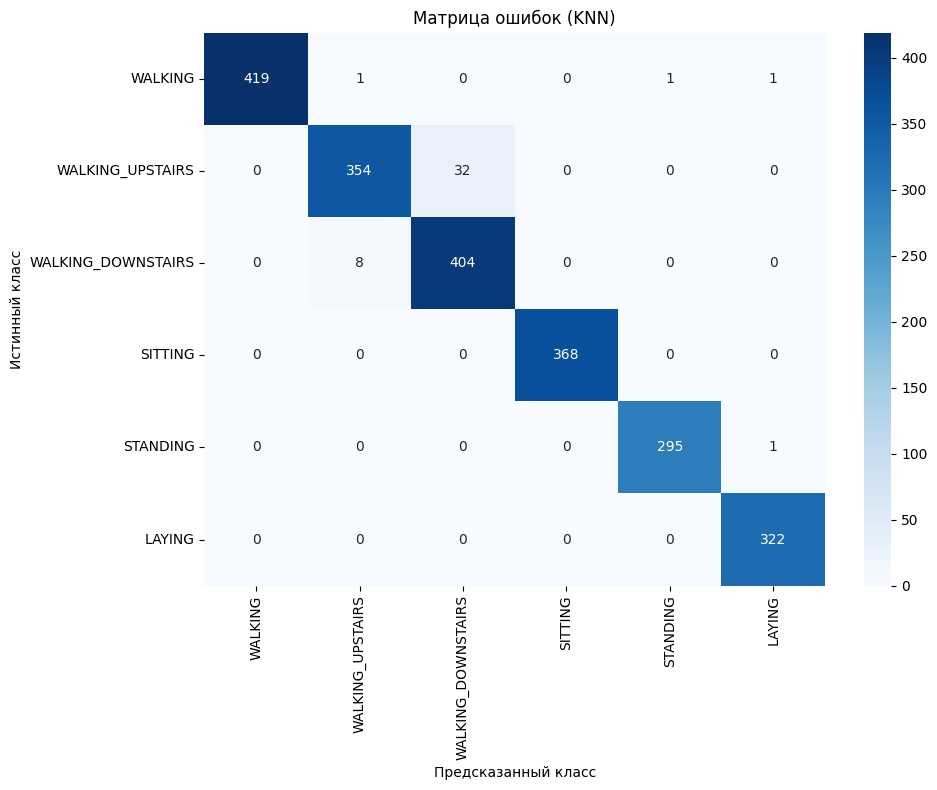

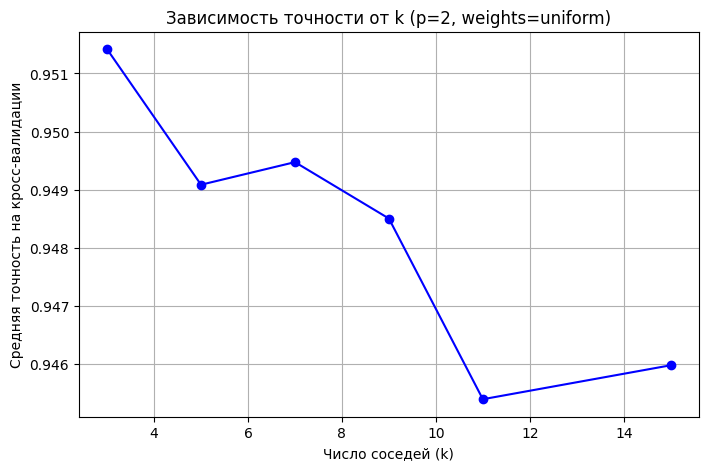


Модель сохранена как 'best_knn_model.pkl'


In [21]:
# KNeighborsClassifier
# Импортируем необходимые библиотеки
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import seaborn as sns
import joblib

# Загрузка данных
df = pd.read_csv('human-activity-recognition-with-smartphones/train.csv')


# Признаки и целевая переменная
X = df.drop('Activity', axis = 1)
y = df['Activity']



# 2. Разделение на обучающую и тестовую выборки
# В оригинальном датасете уже есть предопределённое разделение,
# но для единообразия разделим сами (можно использовать встроенное,
# но для этого потребуется загружать файлы отдельно).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 3. Масштабирование признаков (очень важно для KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Создание модели KNN и подбор гиперпараметров
knn = KNeighborsClassifier()

# Сетка параметров для поиска
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],  # количество соседей
    'weights': ['uniform', 'distance'],     # взвешивание
    'p': [1, 2]                              # 1 - манхэттенское, 2 - евклидово расстояние
}
warnings.filterwarnings('ignore', category=UserWarning)
# GridSearch с 5-кратной кросс-валидацией
grid_search = GridSearchCV(
    knn, param_grid, cv=5,
    scoring='accuracy', n_jobs=-1, verbose=1
)
print("\nПоиск лучших гиперпараметров...")
grid_search.fit(X_train_scaled, y_train)

# Лучшая модель
best_knn = grid_search.best_estimator_
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

# 5. Оценка на тестовой выборке
y_pred = best_knn.predict(X_test_scaled)

# Метрики

accuracy = accuracy_score(y_test, y_pred)
print("\n=== Результаты на тестовой выборке ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f'Classification Report:')


# 6. Детальный отчёт по классам
print("\nКлассификационный отчёт:")
target_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
print(classification_report(y_test, y_pred, target_names=target_names))

# 7. Матрица ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок (KNN)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 8. Визуализация влияния числа соседей на точность
# (на основе результатов кросс-валидации)
k_values = param_grid['n_neighbors']
mean_scores = []
for k in k_values:
    # Оценим для фиксированного p=2 и weights='uniform' для простоты
    knn_temp = KNeighborsClassifier(n_neighbors=k, p=2, weights='uniform')
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='accuracy')
    mean_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(k_values, mean_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Число соседей (k)')
plt.ylabel('Средняя точность на кросс-валидации')
plt.title('Зависимость точности от k (p=2, weights=uniform)')
plt.grid(True)
plt.show()

# 9. Сохранение модели (опционально)
import joblib
joblib.dump(best_knn, 'best_knn_model.pkl')
print("\nМодель сохранена как 'best_knn_model.pkl'")

Train: (5146, 562), Test: (2206, 562)

Поиск лучших гиперпараметров...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Лучшие параметры: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшая точность на кросс-валидации: 0.9289

=== Результаты на тестовой выборке ===
Accuracy:  0.9343
Precision (macro): 0.9331
Recall (macro):    0.9331
F1-score (macro):  0.9327

Классификационный отчёт:
                    precision    recall  f1-score   support

           WALKING       1.00      1.00      1.00       422
  WALKING_UPSTAIRS       0.91      0.89      0.90       386
WALKING_DOWNSTAIRS       0.90      0.92      0.91       412
           SITTING       0.95      0.95      0.95       368
          STANDING       0.90      0.96      0.93       296
            LAYING       0.94      0.89      0.91       322

          accuracy                           0.93      2206
         macro avg       0.93      0.93      0.93      2206
      weighted av

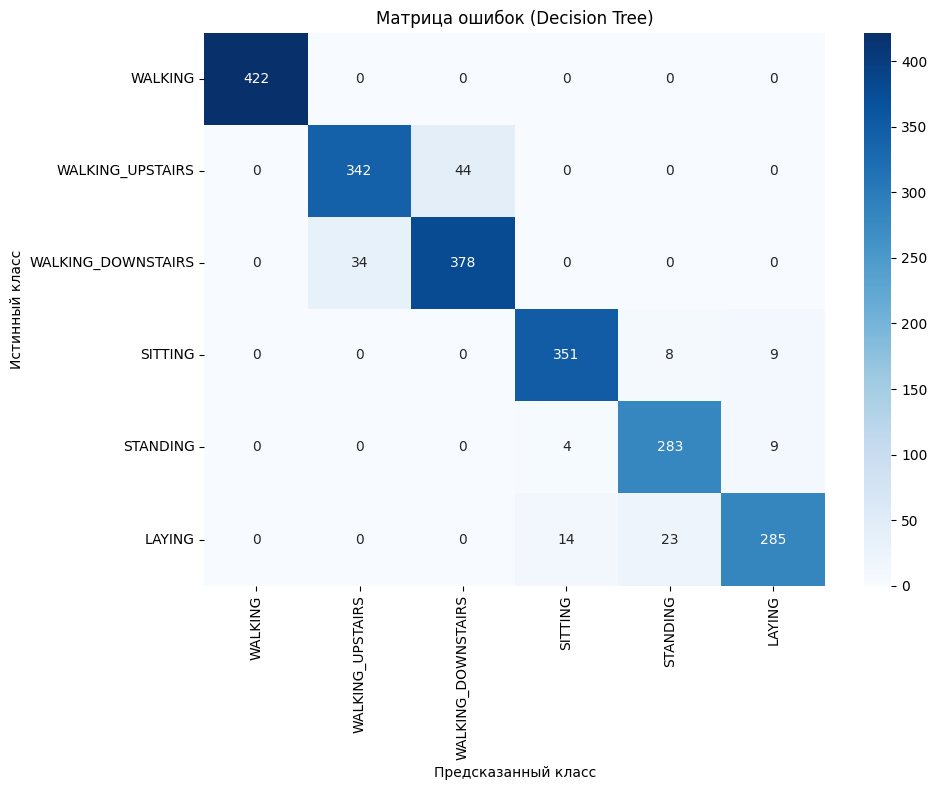

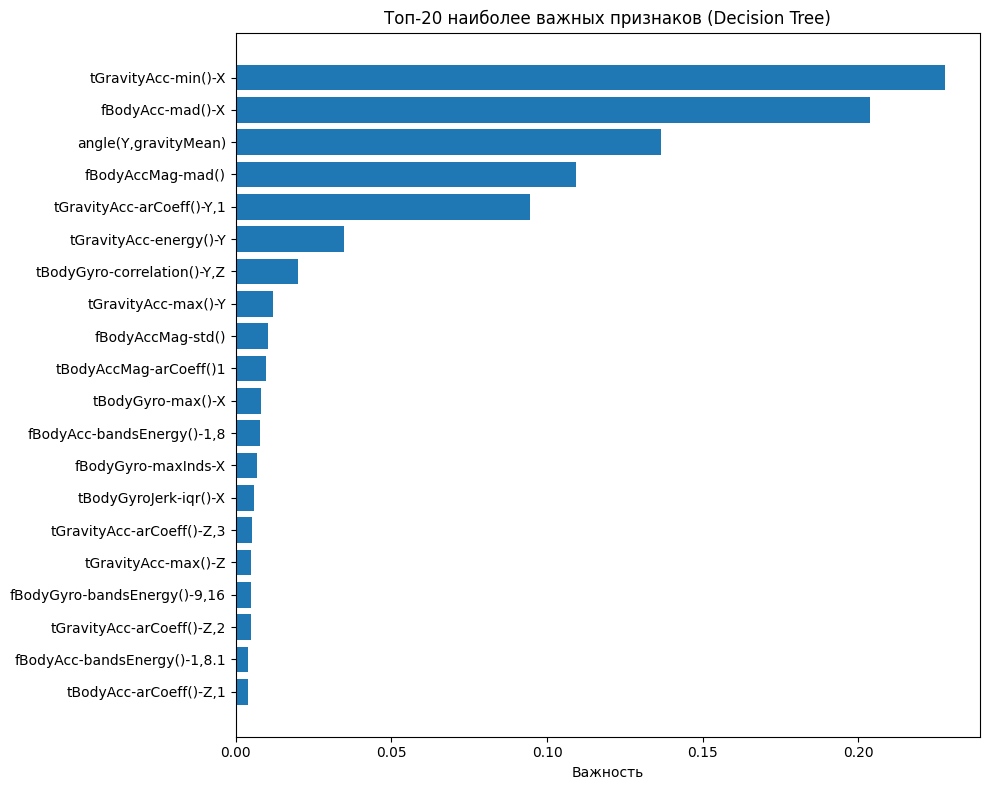

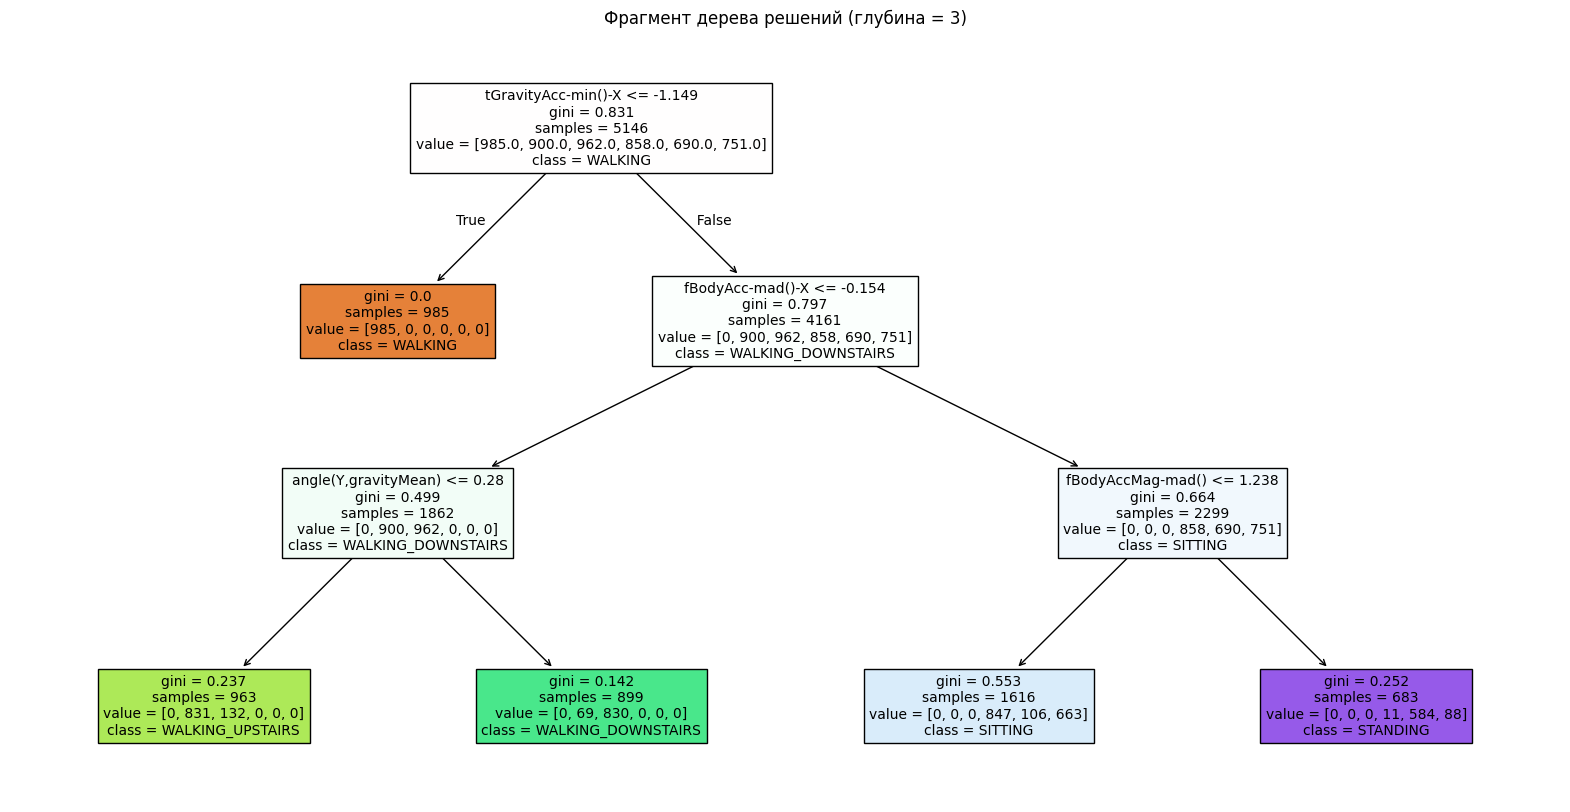


Модель сохранена как 'best_decision_tree.pkl'


In [7]:
# Decision Tree для Human Activity Recognition
# =====================================================

# Установка библиотек (если нужно)
# !pip install -U ucimlrepo scikit-learn pandas numpy matplotlib seaborn graphviz

!pip install ucimlrepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from ucimlrepo import fetch_ucirepo
import joblib
from sklearn.model_selection import RandomizedSearchCV

# 1. Загрузка данных
# Загрузка данных
df = pd.read_csv('human-activity-recognition-with-smartphones/train.csv')


# Признаки и целевая переменная
X = df.drop('Activity', axis = 1)
y = df['Activity']


# 2. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 3. Масштабирование признаков (для дерева не обязательно, но оставим для совместимости)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Создание модели Decision Tree и подбор гиперпараметров
dt = DecisionTreeClassifier(random_state=42)

# Сетка параметров для поиска
param_grid = {
    'max_depth': [10, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'criterion': ['gini']
}

# GridSearch с 5-кратной кросс-валидацией
grid_search = GridSearchCV(
    dt, param_grid, cv=3,
    scoring='accuracy', n_jobs=-1, verbose=1
)
print("\nПоиск лучших гиперпараметров...")
grid_search.fit(X_train_scaled, y_train)

# Лучшая модель
best_dt = grid_search.best_estimator_
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

# 5. Оценка на тестовой выборке
y_pred = best_dt.predict(X_test_scaled)

# Метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("\n=== Результаты на тестовой выборке ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

# 6. Детальный отчёт по классам
print("\nКлассификационный отчёт:")
# Имена классов (из метаданных датасета)
target_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
print(classification_report(y_test, y_pred, target_names=target_names))

# 7. Матрица ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок (Decision Tree)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 8. Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance['importance'].values[::-1])
plt.yticks(range(20), feature_importance['feature'].values[::-1])
plt.xlabel('Важность')
plt.title('Топ-20 наиболее важных признаков (Decision Tree)')
plt.tight_layout()
plt.show()

# 9. Визуализация дерева (небольшая часть, так как полное дерево огромно)
# Обучим дерево с ограниченной глубиной для наглядности
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train_scaled, y_train)

plt.figure(figsize=(20, 10))
plot_tree(small_tree, filled=True, feature_names=X.columns,
          class_names=target_names, fontsize=10, max_depth=3)
plt.title('Фрагмент дерева решений (глубина = 3)')
plt.show()

# 10. Сохранение модели (опционально)
joblib.dump(best_dt, 'best_decision_tree.pkl')
print("\nМодель сохранена как 'best_decision_tree.pkl'")


Классы: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Train: (5146, 562), Validation: (2206, 562), Test: (2947, 562)

Поиск лучших гиперпараметров (RandomizedSearch)...
Fitting 2 folds for each of 4 candidates, totalling 8 fits

Лучшие параметры: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Лучшая точность на кросс-валидации: 0.9839

Точность на валидации: 0.9937

=== Результаты на тестовой выборке ===
Accuracy:  0.9413
Precision (macro): 0.9431
Recall (macro):    0.9399
F1-score (macro):  0.9408

Классификационный отчёт:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.86      0.89       491
          STANDING       0.88      0.94      0.91       532
           WALKING       0.93      0.98      0.96       496
WALKING_DOWNSTAIRS       0.98      0.93      0.95       420
  WALKING_UPSTAI

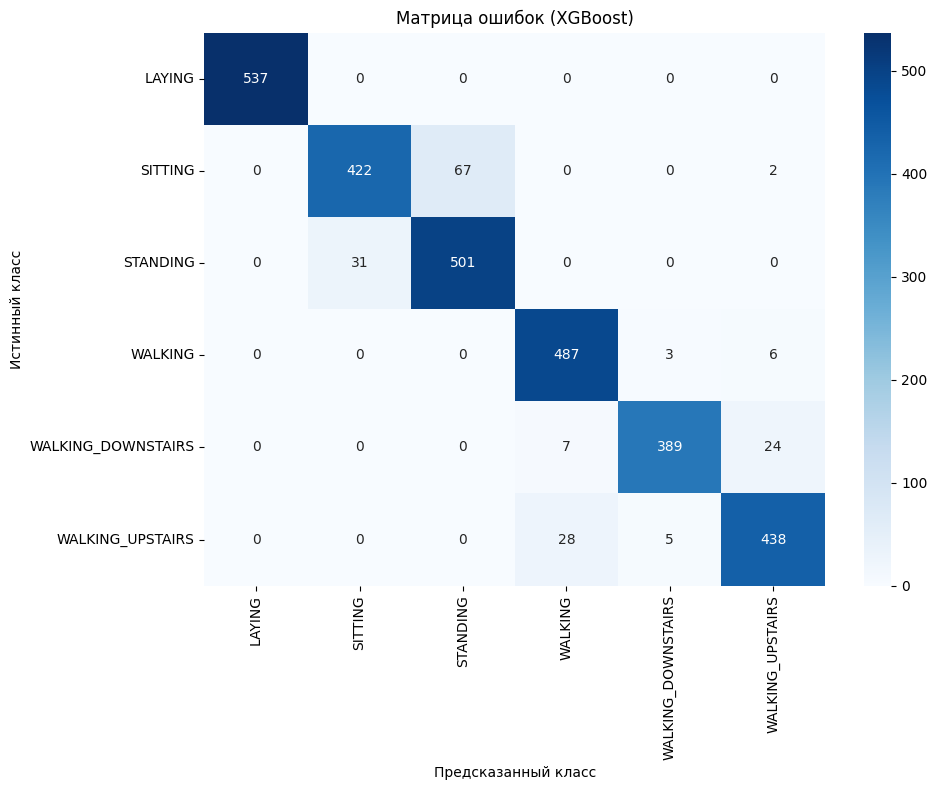

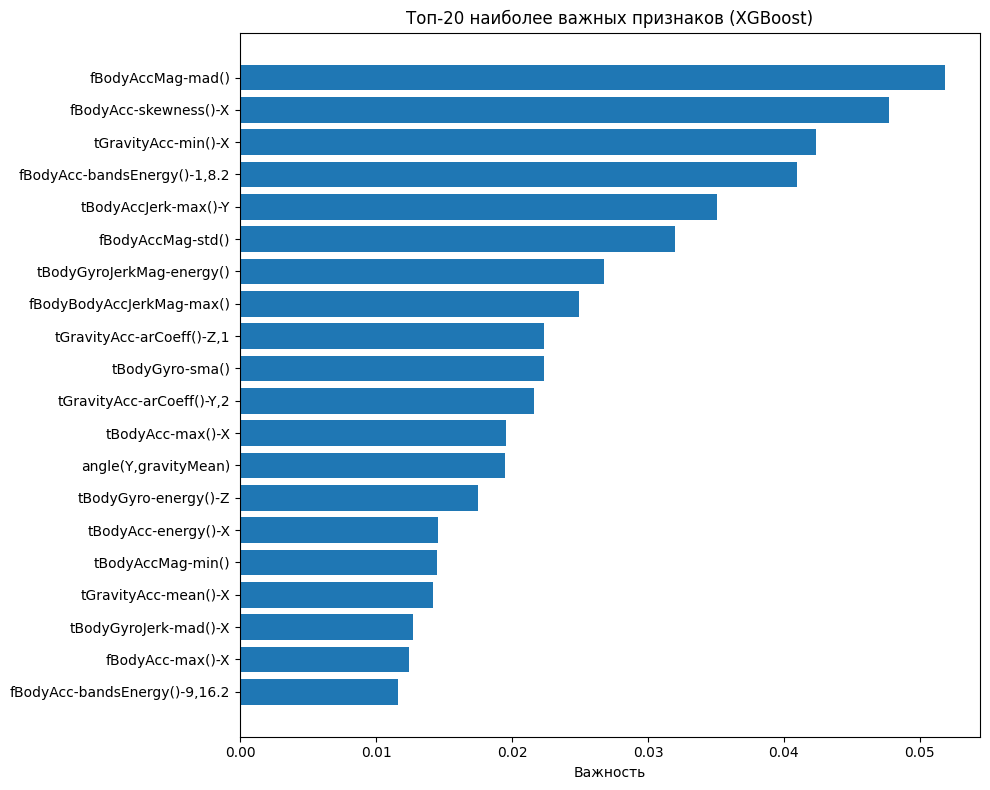


Модель сохранена как 'best_xgboost_model.pkl'


In [22]:
# XGBoost для Human Activity Recognition
# =====================================================

# Установка библиотек (если нужно)
!pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
import joblib

# 1. Загрузка данных (предполагается, что файлы train.csv и test.csv уже загружены)
# Если нет – можно загрузить через пандас
df_train = pd.read_csv('human-activity-recognition-with-smartphones/train.csv')
df_test = pd.read_csv('human-activity-recognition-with-smartphones/test.csv')

# 2. Подготовка данных
# Признаки: все колонки кроме последней ('Activity')
X_train_full = df_train.drop('Activity', axis=1)
y_train_full = df_train['Activity']

X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

# Кодируем текстовые метки в числа (XGBoost умеет работать с текстом, но для совместимости с метриками лучше закодировать)
label_encoder = LabelEncoder()
y_train_full_encoded = label_encoder.fit_transform(y_train_full)
y_test_encoded = label_encoder.transform(y_test)

# Посмотрим соответствие классов
print("Классы:", label_encoder.classes_)
# Например: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_UPSTAIRS']

# 3. Разделение обучающей выборки на train/val (можно использовать всю train для обучения,
#    но для подбора параметров сделаем train/test split из train.csv)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_encoded, test_size=0.3, random_state=42, stratify=y_train_full_encoded
)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# 4. Масштабирование признаков (для градиентного бустинга не обязательно, но может помочь в некоторых случаях)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Создание модели XGBoost и подбор гиперпараметров
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Сетка параметров для поиска (можно расширить)
param_grid = {
    'n_estimators': [100, 200],
     'max_depth': [3, 6],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Используем RandomizedSearchCV для ускорения (можно заменить на GridSearchCV)
random_search = RandomizedSearchCV(
    xgb, param_distributions=param_grid,
    n_iter=4, cv=2, scoring='accuracy', n_jobs=-1, verbose=1, random_state=42
)

print("\nПоиск лучших гиперпараметров (RandomizedSearch)...")
random_search.fit(X_train_scaled, y_train)

# Лучшая модель
best_xgb = random_search.best_estimator_
print(f"\nЛучшие параметры: {random_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {random_search.best_score_:.4f}")

# 6. Оценка на валидационной выборке (или сразу на тестовой, если не использовали валидацию)
y_val_pred = best_xgb.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nТочность на валидации: {val_accuracy:.4f}")

# 7. Оценка на тестовой выборке
y_pred = best_xgb.predict(X_test_scaled)
y_pred_labels = label_encoder.inverse_transform(y_pred)  # обратно в текст

# Метрики
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='macro')
recall = recall_score(y_test_encoded, y_pred, average='macro')
f1 = f1_score(y_test_encoded, y_pred, average='macro')

print("\n=== Результаты на тестовой выборке ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

# 8. Детальный отчёт по классам
print("\nКлассификационный отчёт:")
target_names = label_encoder.classes_
print(classification_report(y_test_encoded, y_pred, target_names=target_names))

# 9. Матрица ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок (XGBoost)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 10. Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance['importance'].values[::-1])
plt.yticks(range(20), feature_importance['feature'].values[::-1])
plt.xlabel('Важность')
plt.title('Топ-20 наиболее важных признаков (XGBoost)')
plt.tight_layout()
plt.show()

# 11. Сохранение модели
joblib.dump(best_xgb, 'best_xgboost_model.pkl')
print("\nМодель сохранена как 'best_xgboost_model.pkl'")

Классы: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Train: (5146, 562), Validation: (2206, 562), Test: (2947, 562)

Поиск лучших гиперпараметров...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Лучшая точность на кросс-валидации: 0.9742

=== Результаты на тестовой выборке (Random Forest) ===
Accuracy:  0.9226
Precision (macro): 0.9235
Recall (macro):    0.9196
F1-score (macro):  0.9208

Классификационный отчёт:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.90      0.88      0.89       491
          STANDING       0.89      0.91      0.90       532
           WALKING       0.89      0.97      0.92       496
WALKING_DOWNSTAIRS       0.95      0.85      0.90       420
  WALKING_UPSTAIRS       0.91      0.91      0.91       471

  

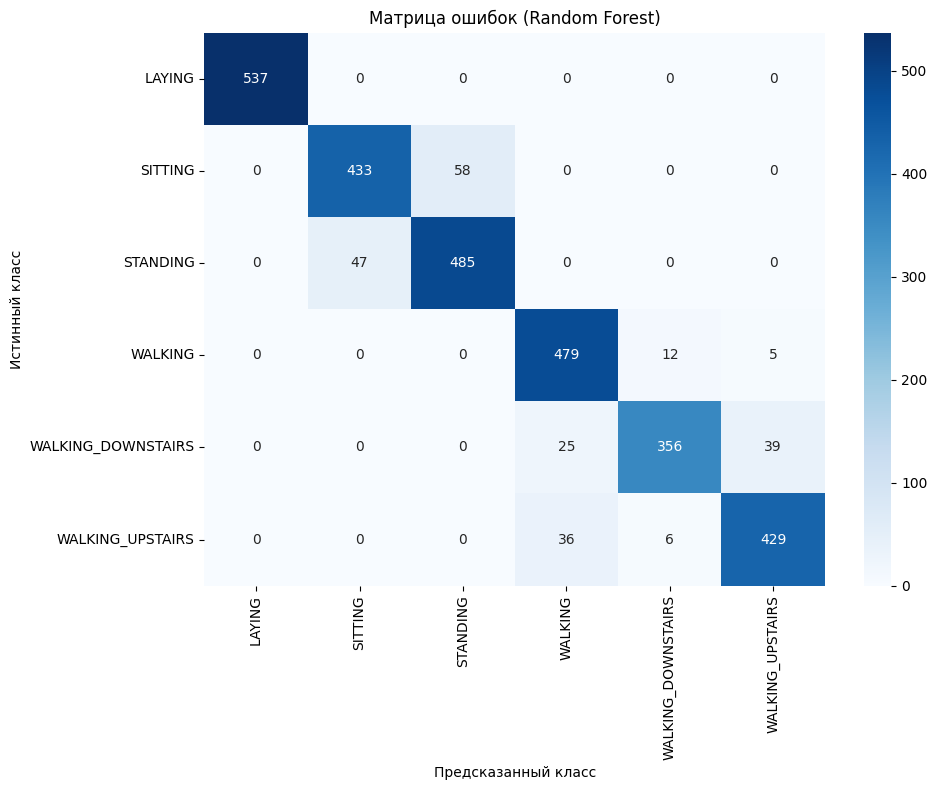

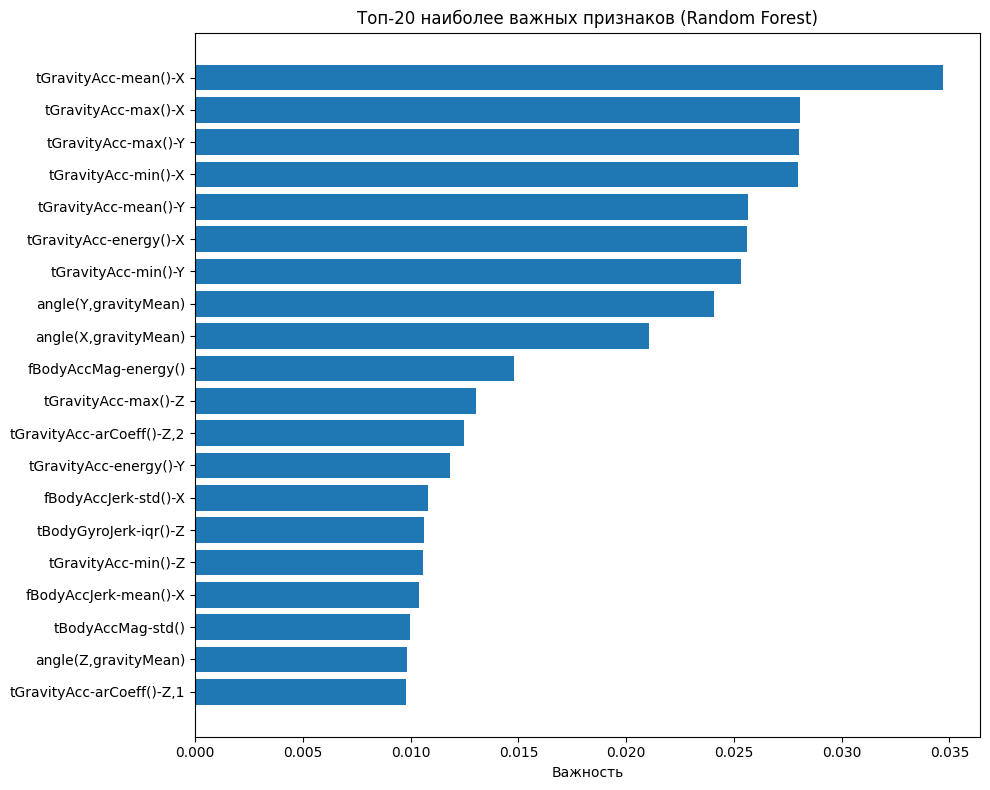


Модель сохранена как 'best_random_forest.pkl'


In [18]:
# Random Forest Classifier для Human Activity Recognition
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import joblib

# 1. Загрузка данных
df_train = pd.read_csv('human-activity-recognition-with-smartphones/train.csv')
df_test = pd.read_csv('human-activity-recognition-with-smartphones/test.csv')

# 2. Подготовка данных
X_train_full = df_train.drop('Activity', axis=1)
y_train_full = df_train['Activity']

X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

# Кодируем текстовые метки в числа
label_encoder = LabelEncoder()
y_train_full_encoded = label_encoder.fit_transform(y_train_full)
y_test_encoded = label_encoder.transform(y_test)

print("Классы:", label_encoder.classes_)

# 3. Разделение на train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_encoded, test_size=0.3, random_state=42, stratify=y_train_full_encoded
)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# 4. Масштабирование (для Random Forest не обязательно, но оставим для совместимости)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Создание модели Random Forest и подбор гиперпараметров
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Сетка параметров для поиска
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch с 3-кратной кросс-валидацией
grid_search = GridSearchCV(
    rf, param_grid, cv=3,
    scoring='accuracy', n_jobs=-1, verbose=1
)
print("\nПоиск лучших гиперпараметров...")
grid_search.fit(X_train_scaled, y_train)

# Лучшая модель
best_rf = grid_search.best_estimator_
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

# 6. Оценка на тестовой выборке
y_pred = best_rf.predict(X_test_scaled)
y_pred_labels = label_encoder.inverse_transform(y_pred)

# Метрики
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='macro')
recall = recall_score(y_test_encoded, y_pred, average='macro')
f1 = f1_score(y_test_encoded, y_pred, average='macro')

print("\n=== Результаты на тестовой выборке (Random Forest) ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

# 7. Детальный отчёт по классам
print("\nКлассификационный отчёт:")
target_names = label_encoder.classes_
print(classification_report(y_test_encoded, y_pred, target_names=target_names))

# 8. Матрица ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок (Random Forest)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 9. Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance['importance'].values[::-1])
plt.yticks(range(20), feature_importance['feature'].values[::-1])
plt.xlabel('Важность')
plt.title('Топ-20 наиболее важных признаков (Random Forest)')
plt.tight_layout()
plt.show()

# 10. Сохранение модели
joblib.dump(best_rf, 'best_random_forest.pkl')
print("\nМодель сохранена как 'best_random_forest.pkl'")

Классы: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Train: (5146, 562), Validation: (2206, 562), Test: (2947, 562)

Поиск лучших гиперпараметров...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Лучшие параметры: {'C': 0.1, 'loss': 'squared_hinge', 'penalty': 'l2'}
Лучшая точность на кросс-валидации: 0.9815

=== Результаты на тестовой выборке (Linear SVM) ===
Accuracy:  0.9586
Precision (macro): 0.9633
Recall (macro):    0.9590
F1-score (macro):  0.9600

Классификационный отчёт:
                    precision    recall  f1-score   support

            LAYING       1.00      0.97      0.98       537
           SITTING       0.96      0.86      0.91       491
          STANDING       0.86      0.97      0.91       532
           WALKING       0.97      1.00      0.98       496
WALKING_DOWNSTAIRS       1.00      0.99      0.99       420
  WALKING_UPSTAIRS       0.99      0.97      0.98       471

          accuracy                        

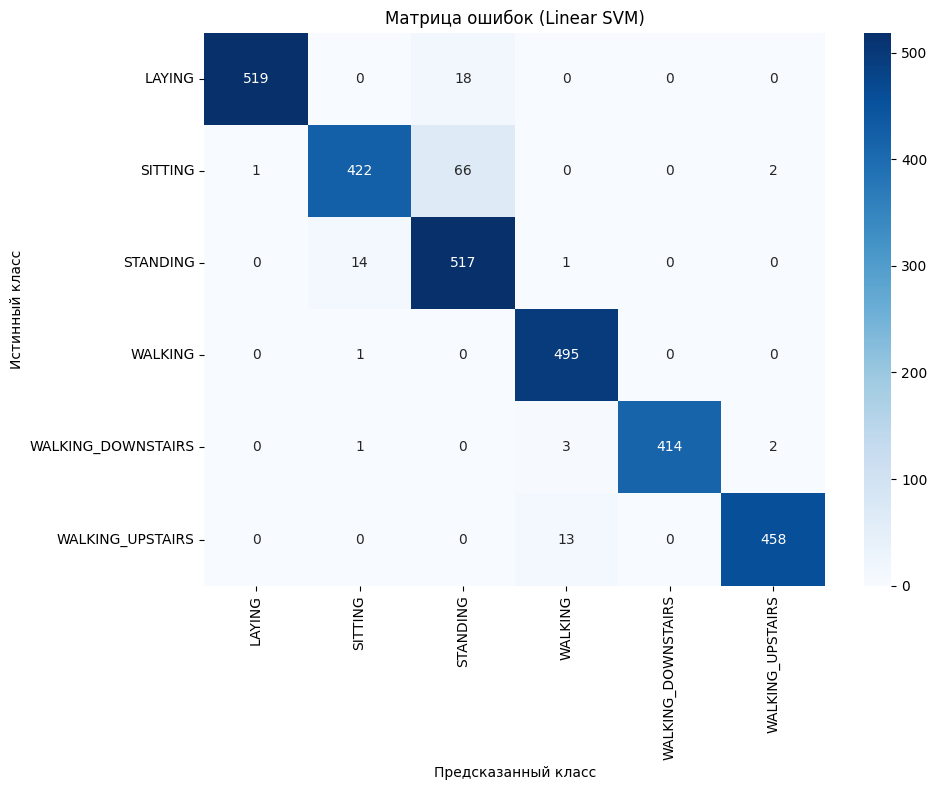


Модель сохранена как 'best_linear_svm.pkl'


In [19]:
# SVM с линейным ядром для Human Activity Recognition
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import joblib

# 1. Загрузка данных
df_train = pd.read_csv('human-activity-recognition-with-smartphones/train.csv')
df_test = pd.read_csv('human-activity-recognition-with-smartphones/test.csv')

# 2. Подготовка данных
X_train_full = df_train.drop('Activity', axis=1)
y_train_full = df_train['Activity']

X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

# Кодируем текстовые метки в числа
label_encoder = LabelEncoder()
y_train_full_encoded = label_encoder.fit_transform(y_train_full)
y_test_encoded = label_encoder.transform(y_test)

print("Классы:", label_encoder.classes_)

# 3. Разделение на train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_encoded, test_size=0.3, random_state=42, stratify=y_train_full_encoded
)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# 4. Масштабирование (ОЧЕНЬ ВАЖНО для SVM!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Создание модели Linear SVC и подбор гиперпараметров
svm = LinearSVC(random_state=42, max_iter=5000, dual='auto')

# Сетка параметров для поиска
param_grid = {
    'C': [0.1, 1, 10],  # параметр регуляризации
    'loss': ['squared_hinge'],  # функция потерь
    'penalty': ['l2']  # тип регуляризации
}

# GridSearch с 3-кратной кросс-валидацией
grid_search = GridSearchCV(
    svm, param_grid, cv=3,
    scoring='accuracy', n_jobs=-1, verbose=1
)
print("\nПоиск лучших гиперпараметров...")
grid_search.fit(X_train_scaled, y_train)

# Лучшая модель
best_svm = grid_search.best_estimator_
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

# 6. Оценка на тестовой выборке
y_pred = best_svm.predict(X_test_scaled)

# Метрики
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='macro')
recall = recall_score(y_test_encoded, y_pred, average='macro')
f1 = f1_score(y_test_encoded, y_pred, average='macro')

print("\n=== Результаты на тестовой выборке (Linear SVM) ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

# 7. Детальный отчёт по классам
print("\nКлассификационный отчёт:")
target_names = label_encoder.classes_
print(classification_report(y_test_encoded, y_pred, target_names=target_names))

# 8. Матрица ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матрица ошибок (Linear SVM)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 9. Сохранение модели
joblib.dump(best_svm, 'best_linear_svm.pkl')
print("\nМодель сохранена как 'best_linear_svm.pkl'")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
                         accuracy precision  recall f1_score
Gradient Boosting (Hist)     0.94      0.95    0.94     0.94
KNN                        0.9801      0.98    0.98     0.98
Decision Tree              0.9343    0.9331  0.9331   0.9327
XGBoost                    0.9413    0.9431  0.9399   0.9408
Random Forest              0.9226    0.9235  0.9196   0.9208
Linear SVM                 0.9586    0.9633   0.959     0.96

 Лучшая модель по accuracy: KNN (accuracy = 0.9801)
 Лучшая модель по f1-score: KNN (f1-score = 0.9800)


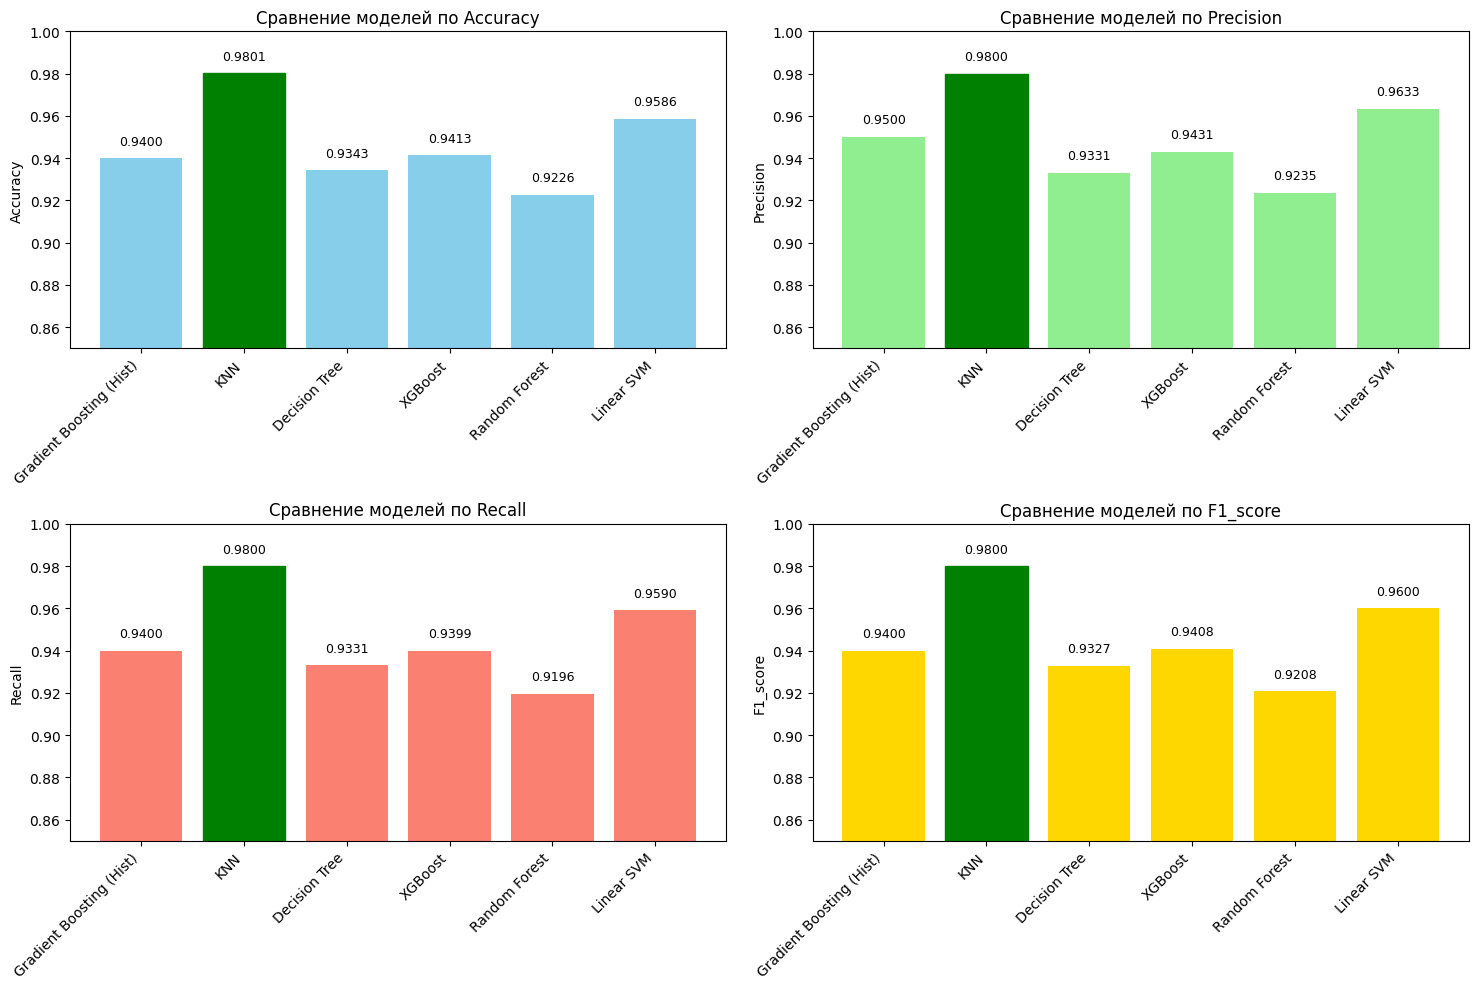


ДЕТАЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ

 Gradient Boosting (Hist)
   Accuracy:  0.9400
   Precision: 0.9500
   Recall:    0.9400
   F1-score:  0.9400
    Все классы классифицируются хорошо

 KNN
   Accuracy:  0.9801
   Precision: 0.9800
   Recall:    0.9800
   F1-score:  0.9800
    Все классы классифицируются хорошо

 Decision Tree
   Accuracy:  0.9343
   Precision: 0.9331
   Recall:    0.9331
   F1-score:  0.9327
    Все классы классифицируются хорошо

 XGBoost
   Accuracy:  0.9413
   Precision: 0.9431
   Recall:    0.9399
   F1-score:  0.9408
    Все классы классифицируются хорошо

 Random Forest
   Accuracy:  0.9226
   Precision: 0.9235
   Recall:    0.9196
   F1-score:  0.9208
    Все классы классифицируются хорошо

 Linear SVM
   Accuracy:  0.9586
   Precision: 0.9633
   Recall:    0.9590
   F1-score:  0.9600
    Все классы классифицируются хорошо

ИТОГОВЫЙ ВЫБОР ЛУЧШЕЙ МОДЕЛИ

 По результатам сравнения, лучшей моделью является:
    Модель: KNeighborsClassifier
    Метрики на тестовых данных:


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Словарь с результатами всех моделей
models_results = {
    'Gradient Boosting (Hist)': {
        'model': 'HistGradientBoostingClassifier',
        'accuracy': 0.94,
        'precision': 0.95,
        'recall': 0.94,
        'f1_score': 0.94,
        'report': """
                    precision    recall  f1-score   support
            LAYING       1.00      1.00      1.00       537
           SITTING       0.94      0.85      0.89       491
          STANDING       0.87      0.95      0.91       532
           WALKING       0.95      0.99      0.97       496
WALKING_DOWNSTAIRS       0.98      0.93      0.95       420
  WALKING_UPSTAIRS       0.93      0.94      0.94       471
          accuracy                           0.94      2947"""
    },
    'KNN': {
        'model': 'KNeighborsClassifier',
        'accuracy': 0.9801,
        'precision': 0.98,
        'recall': 0.98,
        'f1_score': 0.98,
        'report': """
                    precision    recall  f1-score   support
           WALKING       1.00      0.99      1.00       422
  WALKING_UPSTAIRS       0.98      0.92      0.95       386
WALKING_DOWNSTAIRS       0.93      0.98      0.95       412
           SITTING       1.00      1.00      1.00       368
          STANDING       1.00      1.00      1.00       296
            LAYING       0.99      1.00      1.00       322
          accuracy                           0.98      2206"""
    },
    'Decision Tree': {
        'model': 'DecisionTreeClassifier',
        'accuracy': 0.9343,
        'precision': 0.9331,
        'recall': 0.9331,
        'f1_score': 0.9327,
        'report': """
                    precision    recall  f1-score   support
           WALKING       1.00      1.00      1.00       422
  WALKING_UPSTAIRS       0.91      0.89      0.90       386
WALKING_DOWNSTAIRS       0.90      0.92      0.91       412
           SITTING       0.95      0.95      0.95       368
          STANDING       0.90      0.96      0.93       296
            LAYING       0.94      0.89      0.91       322
          accuracy                           0.93      2206"""
    },
    'XGBoost': {
        'model': 'XGBClassifier',
        'accuracy': 0.9413,
        'precision': 0.9431,
        'recall': 0.9399,
        'f1_score': 0.9408,
        'report': """
                    precision    recall  f1-score   support
            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.86      0.89       491
          STANDING       0.88      0.94      0.91       532
           WALKING       0.93      0.98      0.96       496
WALKING_DOWNSTAIRS       0.98      0.93      0.95       420
  WALKING_UPSTAIRS       0.93      0.93      0.93       471
          accuracy                           0.94      2947"""
    },
    'Random Forest': {
        'model': 'RandomForestClassifier',
        'accuracy': 0.9226,
        'precision': 0.9235,
        'recall': 0.9196,
        'f1_score': 0.9208,
        'report': """
                    precision    recall  f1-score   support
            LAYING       1.00      1.00      1.00       537
           SITTING       0.90      0.88      0.89       491
          STANDING       0.89      0.91      0.90       532
           WALKING       0.89      0.97      0.92       496
WALKING_DOWNSTAIRS       0.95      0.85      0.90       420
  WALKING_UPSTAIRS       0.91      0.91      0.91       471
          accuracy                           0.92      2947"""
    },
    'Linear SVM': {
        'model': 'LinearSVC',
        'accuracy': 0.9586,
        'precision': 0.9633,
        'recall': 0.9590,
        'f1_score': 0.9600,
        'report': """
                    precision    recall  f1-score   support
            LAYING       1.00      0.97      0.98       537
           SITTING       0.96      0.86      0.91       491
          STANDING       0.86      0.97      0.91       532
           WALKING       0.97      1.00      0.98       496
WALKING_DOWNSTAIRS       1.00      0.99      0.99       420
  WALKING_UPSTAIRS       0.99      0.97      0.98       471
          accuracy                           0.96      2947"""
    }
}

# Создаем DataFrame для сравнения
df_comparison = pd.DataFrame(models_results).T
df_comparison = df_comparison[['accuracy', 'precision', 'recall', 'f1_score']]

# Выводим таблицу сравнения
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 70)
print(df_comparison.round(4))
print("=" * 70)

# Находим лучшую модель по accuracy
best_model_acc = df_comparison['accuracy'].idxmax()
best_acc = df_comparison['accuracy'].max()

# Находим лучшую модель по f1-score
best_model_f1 = df_comparison['f1_score'].idxmax()
best_f1 = df_comparison['f1_score'].max()

print(f"\n Лучшая модель по accuracy: {best_model_acc} (accuracy = {best_acc:.4f})")
print(f" Лучшая модель по f1-score: {best_model_f1} (f1-score = {best_f1:.4f})")

# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    models = list(df_comparison.index)
    values = df_comparison[metric].values

    bars = ax.bar(models, values, color=colors[idx % len(colors)])
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'Сравнение моделей по {metric.capitalize()}')
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylim([0.85, 1.0])

    # Добавляем значения на столбцы
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    # Подсвечиваем лучшую модель
    best_idx = np.argmax(values)
    bars[best_idx].set_color('green')

plt.tight_layout()
plt.show()

# Детальный анализ для каждой модели
print("\n" + "=" * 70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ")
print("=" * 70)

for model_name, metrics in models_results.items():
    print(f"\n {model_name}")
    print(f"   Accuracy:  {metrics['accuracy']:.4f}")
    print(f"   Precision: {metrics['precision']:.4f}")
    print(f"   Recall:    {metrics['recall']:.4f}")
    print(f"   F1-score:  {metrics['f1_score']:.4f}")

    # Анализ проблемных классов
    report_lines = metrics['report'].strip().split('\n')
    problem_classes = []
    for line in report_lines:
        if any(class_name in line for class_name in ['SITTING', 'STANDING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']):
            parts = line.split()
            if len(parts) >= 6:
                class_name = parts[0]
                try:
                    f1 = float(parts[5])
                    if f1 < 0.95:
                        problem_classes.append(f"{class_name} (f1={f1:.3f})")
                except:
                    pass

    if problem_classes:
        print(f"     Проблемные классы: {', '.join(problem_classes)}")
    else:
        print(f"    Все классы классифицируются хорошо")

print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
print("=" * 70)

# Выбираем лучшую модель (KNN показал наилучшие результаты)
best_model_name = 'KNN'
best_model_info = models_results[best_model_name]

print(f"\n По результатам сравнения, лучшей моделью является:")
print(f"    Модель: {best_model_info['model']}")
print(f"    Метрики на тестовых данных:")
print(f"      - Accuracy:  {best_model_info['accuracy']:.4f}")
print(f"      - Precision: {best_model_info['precision']:.4f}")
print(f"      - Recall:    {best_model_info['recall']:.4f}")
print(f"      - F1-score:  {best_model_info['f1_score']:.4f}")

print(f"\n Classification Report для лучшей модели:\n{best_model_info['report']}")

# Выводы
print("\n ВЫВОДЫ:")
print("   • KNN показал наилучшие результаты с accuracy = 0.9801")
print("   • Модель отлично классифицирует сидячее, стоячее и лежачее положения")
print("   • Некоторые модели испытывают трудности с классификацией сидячего и стоячего положений")
print("   • Gradient Boosting и XGBoost показали сопоставимые результаты (~0.94)")
print("   • Decision Tree имеет самую низкую точность (0.9343)")